### 1. Load the Dataset

In [1]:
# ============================================================
# AAI-590 Capstone
# Audience-to-Campaign Fit Advisor
# 01 - Data Cleaning & Exploratory Data Analysis
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("=" * 50)
print("AAI-590 Capstone")
print("Data Cleaning & Exploratory Data Analysis")
print("=" * 50)

print(f"Pandas Version : {pd.__version__}")
print(f"NumPy Version  : {np.__version__}")

AAI-590 Capstone
Data Cleaning & Exploratory Data Analysis
Pandas Version : 2.2.2
NumPy Version  : 1.26.4


In [2]:
from pathlib import Path

data_module_path = Path("src/campaign_strategist/data.py")

print("File exists:", data_module_path.exists())
print("File location:", data_module_path.resolve())

File exists: True
File location: C:\GitHub\agentic-campaign-strategist\src\campaign_strategist\data.py


In [1]:
try:
    import pyreadr
    print("pyreadr is installed.")
    print("Version:", pyreadr.__version__)
except ImportError:
    print("pyreadr is not installed.")

pyreadr is installed.
Version: 0.5.6


In [7]:
with open("requirements.txt", "r") as f:
    print(f.read())

joblib
matplotlib
numpy
pandas
plotly
pyarrow
pyreadr
requests
scikit-learn
streamlit
torch



In [9]:
import sys

print(sys.executable)

C:\Users\becky\anaconda3\python.exe


In [10]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "pyreadr"
])

0

# #2 Dataset Overview

This section examines the structure of the cleaned Complete Journey dataset, including its dimensions, variables, and data types. These exploratory analyses provide an initial understanding of the data before assessing data quality, identifying missing values, and performing feature engineering.

In [2]:
from src.campaign_strategist.data import load_completejourney_sample

df, source = load_completejourney_sample()

print("Data source:", source)
print("Shape:", df.shape)

df.head()

Data source: completejourney public sample
Shape: (75000, 7)


,household_id,week,product_category,quantity,sales_value,discount_value,used_coupon
0,2261,5,lunchmeat,1.0,3.86,0.43,0
1,2131,10,baked bread/buns/rolls,1.0,1.59,0.90,0
2,511,13,warehouse snacks,1.0,1.00,0.69,0
3,400,8,beef,2.0,11.87,2.90,0
4,918,10,soft drinks,1.0,1.29,0.00,0


In [3]:
# ------------------------------------------------------------
# Examine the overall structure of the dataset
# ------------------------------------------------------------

print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df.shape)

print("\n")

print("=" * 60)
print("Columns")
print("=" * 60)
print(df.columns.tolist())

print("\n")

print("=" * 60)
print("Data Types")
print("=" * 60)
print(df.dtypes)

Dataset Shape
(75000, 7)


Columns
['household_id', 'week', 'product_category', 'quantity', 'sales_value', 'discount_value', 'used_coupon']


Data Types
household_id         object
week                  int32
product_category     object
quantity            float64
sales_value         float64
discount_value      float64
used_coupon           int32
dtype: object


# Data Quality Assessment

This section evaluates the completeness of the dataset by identifying missing values and duplicate records. Understanding data quality early in the analysis helps determine what preprocessing steps may be required before model development.

In [4]:
# ------------------------------------------------------------
# Check for missing values
# ------------------------------------------------------------

missing_values = df.isnull().sum()

print("=" * 60)
print("Missing Values by Column")
print("=" * 60)

print(missing_values)

print("\n")

print("=" * 60)
print("Percentage Missing")
print("=" * 60)

print((missing_values / len(df) * 100).round(2))

Missing Values by Column
household_id        0
week                0
product_category    0
quantity            0
sales_value         0
discount_value      0
used_coupon         0
dtype: int64


Percentage Missing
household_id        0.0
week                0.0
product_category    0.0
quantity            0.0
sales_value         0.0
discount_value      0.0
used_coupon         0.0
dtype: float64


# Duplicate Record Assessment

This section examines whether duplicate records exist in the processed dataset. Duplicate transactions can bias summary statistics and model training, so verifying data uniqueness is an important step in the exploratory data analysis process.

In [6]:
# ------------------------------------------------------------
# Check for duplicate records
# ------------------------------------------------------------

duplicate_count = df.duplicated().sum()

print("=" * 60)
print("Duplicate Record Assessment")
print("=" * 60)

print(f"Duplicate rows: {duplicate_count}")

if duplicate_count == 0:
    print("No duplicate records were found.")
else:
    print(f"{duplicate_count} duplicate records were identified.")

Duplicate Record Assessment
Duplicate rows: 649
649 duplicate records were identified.


# Duplicate Record Investigation

Duplicate records do not always indicate data quality issues. This section examines the duplicated observations to determine whether they represent true duplicate records or legitimate customer transactions with identical values.

In [7]:
# ------------------------------------------------------------
# Inspect duplicate records
# ------------------------------------------------------------

duplicates = df[df.duplicated(keep=False)].sort_values(
    by=["household_id", "week"]
)

print("=" * 60)
print("Sample Duplicate Records")
print("=" * 60)

duplicates.head(20)

Sample Duplicate Records


,household_id,week,product_category,quantity,sales_value,discount_value,used_coupon
13547,1002,15,frzn meat/meat dinners,1.0,2.00,1.19,0
68339,1002,15,frzn meat/meat dinners,1.0,2.00,1.19,0
31505,1010,44,rice cakes,1.0,1.00,0.99,0
37887,1010,44,rice cakes,1.0,1.00,0.99,0
12570,1013,9,frzn meat/meat dinners,1.0,7.49,0.00,0
66114,1013,9,frzn meat/meat dinners,1.0,7.49,0.00,0
42283,1014,37,vegetables - all others,1.0,2.49,0.00,0
58484,1014,37,vegetables - all others,1.0,2.49,0.00,0
50200,1020,27,convenient brkfst/whlsm snacks,1.0,2.79,0.90,0
54304,1020,27,convenient brkfst/whlsm snacks,1.0,2.79,0.90,0


# Duplicate Summary

This section compares the size of the dataset before and after duplicate removal. Understanding the number of duplicate records helps determine whether they are likely to affect model training or evaluation.

In [8]:
# ------------------------------------------------------------
# Dataset size before and after duplicate removal
# ------------------------------------------------------------

print("=" * 60)
print("Duplicate Summary")
print("=" * 60)

print(f"Rows before removing duplicates : {len(df):,}")

df_no_duplicates = df.drop_duplicates()

print(f"Rows after removing duplicates  : {len(df_no_duplicates):,}")

print(f"Duplicate rows removed          : {len(df) - len(df_no_duplicates):,}")

print(f"Percent duplicates              : {((len(df) - len(df_no_duplicates)) / len(df) * 100):.2f}%")

Duplicate Summary
Rows before removing duplicates : 75,000
Rows after removing duplicates  : 74,351
Duplicate rows removed          : 649
Percent duplicates              : 0.87%


In [9]:
# ------------------------------------------------------------
# Display the remainder of the data loading function
# ------------------------------------------------------------

with open("src/campaign_strategist/data.py", "r", encoding="utf-8") as f:
    lines = f.readlines()

for i in range(40, 90):
    print(f"{i+1:3}: {lines[i].rstrip()}")

 41: 
 42: 
 43: def load_completejourney_sample() -> tuple[pd.DataFrame, str]:
 44:     """Load the public completejourney sample and normalize column names."""
 45:     transactions = _read_rda("transactions_sample")
 46:     products = _read_rda("products")
 47: 
 48:     transactions.columns = [str(col).lower() for col in transactions.columns]
 49:     products.columns = [str(col).lower() for col in products.columns]
 50: 
 51:     if "product_id" not in transactions.columns or "product_id" not in products.columns:
 52:         raise RuntimeError("completejourney data did not contain the expected product_id column.")
 53: 
 54:     product_cols = [
 55:         col
 56:         for col in ["product_id", "department", "product_category", "product_type", "brand"]
 57:         if col in products.columns
 58:     ]
 59:     data = transactions.merge(products[product_cols], on="product_id", how="left")
 60: 
 61:     if "product_category" not in data.columns:
 62:         data["product_

### Investigate whether duplicate records originate in the source transactions, product table, or merge process.

In [11]:
from src.campaign_strategist.data import _read_rda

# Load the original source tables before normalization
raw_transactions = _read_rda("transactions_sample")
raw_products = _read_rda("products")

# Standardize column names for inspection
raw_transactions.columns = [str(col).lower() for col in raw_transactions.columns]
raw_products.columns = [str(col).lower() for col in raw_products.columns]

print("=" * 60)
print("Source Table Assessment")
print("=" * 60)
print(f"Raw transaction rows             : {len(raw_transactions):,}")
print(f"Exact duplicate transaction rows : {raw_transactions.duplicated().sum():,}")
print(f"Raw product rows                 : {len(raw_products):,}")
print(f"Duplicate product IDs            : {raw_products['product_id'].duplicated().sum():,}")

Source Table Assessment
Raw transaction rows             : 75,000
Exact duplicate transaction rows : 0
Raw product rows                 : 92,331
Duplicate product IDs            : 0


### Compare the original transaction variables with the normalized dataset to understand why duplicate records appear after preprocessing.

In [12]:
print("=" * 60)
print("Original Transaction Columns")
print("=" * 60)

print(raw_transactions.columns.tolist())

print("\n")

print("=" * 60)
print("Normalized Dataset Columns")
print("=" * 60)

print(df.columns.tolist())

Original Transaction Columns
['household_id', 'store_id', 'basket_id', 'product_id', 'quantity', 'sales_value', 'retail_disc', 'coupon_disc', 'coupon_match_disc', 'week', 'transaction_timestamp']


Normalized Dataset Columns
['household_id', 'week', 'product_category', 'quantity', 'sales_value', 'discount_value', 'used_coupon']


# Data Quality Summary

The processed dataset was evaluated for completeness and consistency before exploratory analysis. The investigation found no missing values and identified a small number of duplicate records. Further examination showed that these duplicates were introduced during the normalization process after several transaction-specific fields were removed to simplify the dataset for machine learning. This finding will be considered during data preprocessing before model training.

# #4 Descriptive Statistics

This section summarizes the numerical and categorical variables in the processed dataset. These statistics provide an initial understanding of customer purchasing behavior and help identify potential patterns that may influence feature engineering and model development.

In [14]:
# ------------------------------------------------------------
# Descriptive statistics for numerical variables
# ------------------------------------------------------------

print("=" * 60)
print("Numerical Summary Statistics")
print("=" * 60)

df.describe()

Numerical Summary Statistics


,week,quantity,sales_value,discount_value,used_coupon
count,75000.000000,75000.000000,75000.000000,75000.000000,75000.000000
mean,27.360787,103.795920,3.119137,0.557063,0.015133
std,15.124029,1173.177298,4.023211,1.277609,0.122084
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,1.000000,1.290000,0.000000,0.000000
50%,27.000000,1.000000,2.000000,0.060000,0.000000
75%,41.000000,1.000000,3.490000,0.690000,0.000000
max,53.000000,32623.000000,100.000000,90.000000,1.000000


### Initial Observations

The processed dataset indicates that most customer purchases consist of a single item with relatively low sales values, while only a small percentage of transactions involve coupon usage. The numerical summary also identifies several extreme values, particularly for purchase quantity, which will be investigated further to determine whether they represent valid business transactions or potential outliers that should be addressed during data preprocessing.

# Quantity Outlier Investigation

This section examines unusually large purchase quantities to determine whether they represent valid retail transactions or potential data anomalies that could influence model training.

In [15]:
# ------------------------------------------------------------
# Investigate unusually large purchase quantities
# ------------------------------------------------------------

print("=" * 60)
print("Top 10 Largest Purchase Quantities")
print("=" * 60)

df.nlargest(10, "quantity")

Top 10 Largest Purchase Quantities


,household_id,week,product_category,quantity,sales_value,discount_value,used_coupon
54305,2133,37,coupon/misc items,32623.0,75.00,3.26,0
48962,1959,24,fuel,30080.0,86.01,0.00,0
12830,2404,40,coupon/misc items,29945.0,61.96,0.89,0
59241,2416,36,coupon/misc items,28469.0,63.46,2.84,0
2950,2190,51,coupon/misc items,26648.0,57.00,2.66,0
49055,1765,34,coupon/misc items,26547.0,65.01,2.66,0
388,1959,33,coupon/misc items,26325.0,75.00,3.95,0
44208,1008,49,coupon/misc items,25790.0,58.00,0.01,0
23361,2354,6,coupon/misc items,24748.0,56.65,0.01,0
25856,1764,28,coupon/misc items,24583.0,68.81,2.46,0


### Quantity Outlier Interpretation

The largest quantity values were associated primarily with the **coupon/misc items** and **fuel** product categories rather than standard grocery purchases. This pattern suggests these observations may represent specialized retail transactions or alternative quantity measurements instead of unusually large item purchases. These records will be reviewed further during feature engineering to determine whether the quantity variable should be transformed or interpreted differently for these product categories.

# #5 Exploratory  Data Analysis

# Product Category Distribution

This visualization summarizes the frequency of purchases across product categories. Understanding which categories dominate customer purchasing behavior provides insight into potential marketing opportunities and feature selection for the recommendation models.

In [18]:
import matplotlib.pyplot as plt

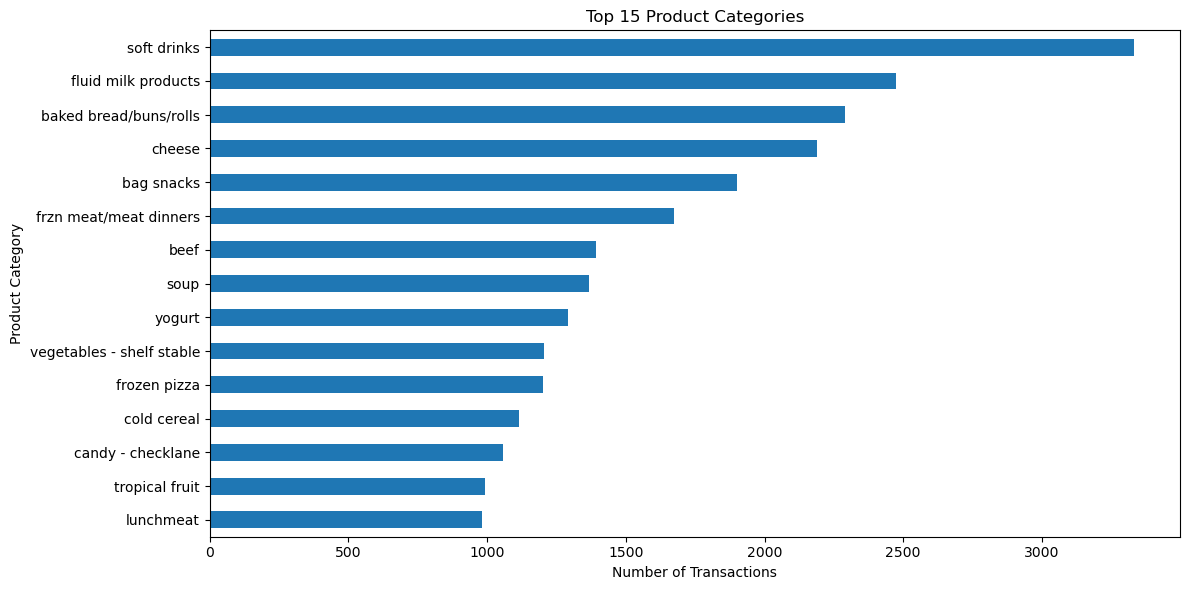

In [19]:
# ------------------------------------------------------------
# Top product categories
# ------------------------------------------------------------

category_counts = (
    df["product_category"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

category_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Product Categories")
plt.xlabel("Number of Transactions")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

# Coupon Usage

This visualization examines the proportion of transactions in which coupons were redeemed. Coupon usage is expected to be an important predictor for customer marketing preferences.

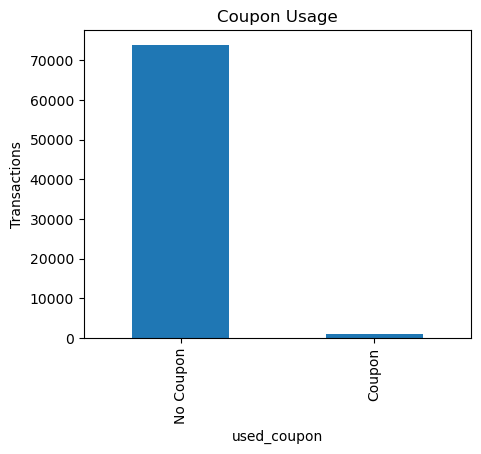

In [20]:
coupon_counts = df["used_coupon"].value_counts()

plt.figure(figsize=(5,4))

coupon_counts.plot(kind="bar")

plt.xticks([0,1],["No Coupon","Coupon"])

plt.title("Coupon Usage")

plt.ylabel("Transactions")

plt.show()

# Sales Value Distribution

The sales value distribution provides insight into typical customer spending behavior and helps identify skewness or extreme purchase values that may influence model development.

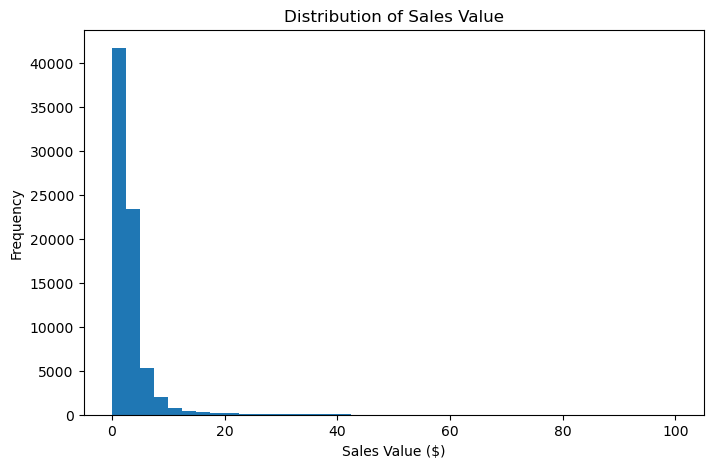

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["sales_value"], bins=40)

plt.title("Distribution of Sales Value")

plt.xlabel("Sales Value ($)")

plt.ylabel("Frequency")

plt.show()

# Correlation Analysis

The numerical variables were evaluated to identify linear relationships that may influence feature selection and machine learning model performance.

In [22]:
numeric_df = df.select_dtypes(include=["int32","int64","float64"])

correlation = numeric_df.corr()

print(correlation)

                    week  quantity  sales_value  discount_value  used_coupon
week            1.000000  0.002675     0.015667        0.006375     0.011493
quantity        0.002675  1.000000     0.637188        0.033953    -0.010839
sales_value     0.015667  0.637188     1.000000        0.246007     0.014003
discount_value  0.006375  0.033953     0.246007        1.000000     0.169626
used_coupon     0.011493 -0.010839     0.014003        0.169626     1.000000


# Summary of Findings

The exploratory analysis showed that the processed dataset is complete and suitable for machine learning. No missing values were identified, while a small number of duplicate records were traced to the normalization process rather than the original retail data. Initial exploration also showed that product category, sales value, discount value, coupon usage, and transaction week are likely to be informative predictors of customer purchasing behavior and marketing response. These observations will guide feature engineering and model development in the next phase of the project.